# Cas d'usage certif — Orientation et tri multimodal des demandeurs d'emploi


# 0 Imports et constantes

In [1]:
import hashlib, json, platform, random, subprocess, sys
from datetime import datetime, timezone
from importlib import metadata
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42                      # une seule graine, partout
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("../../dataset_trajectoire_emploi_Sujet.csv")
OUTPUT_DIR = Path("../../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET = "classe_retour_emploi"
CLASS_LABELS = {0: "Rapide (< 6 mois)", 1: "Moyen (6-12 mois)", 2: "Longue durée (> 12 mois)"}

---
# 1 Cadrage

**Objectif** : poser par écrit le besoin, la tâche, les métriques et les risques **avant** de toucher aux données.

## 1.1 Besoin métier

Une agence nationale de l'emploi doit **aiguiller rapidement** les demandeurs d'emploi à l'issue du premier entretien. L'enjeu : repérer très tôt les usagers à risque de **chômage de longue durée** pour leur proposer un accompagnement renforcé, sans mobiliser ce dispositif pour ceux qui retrouveront un emploi rapidement.

L'outil est une **aide à la décision** pour le conseiller (qui garde la main), pas une décision automatique.

> **Ce que dit le sujet** : « repérer très tôt les usagers à risque de chômage de longue durée » pour un « aiguillage rapide et fiable ». **Ce qu'on en comprend** : il ne s'agit pas de remplacer la décision du conseiller mais de lui fournir un signal de risque priorisé, avant l'entretien ou juste après, pour l'aider à arbitrer *qui* mérite un accompagnement renforcé — l'IA ne doit jamais décider seule (cf. RGPD art. 22).

## 1.2 Tâche ML

- **Apprentissage supervisé**, classification **multiclasse ordonnée** (0 < 1 < 2) : 0 = retour rapide (< 6 mois), 1 = moyen (6-12 mois), 2 = longue durée (> 12 mois).
- **Données hybrides** : tabulaires (âge, diplôme, ancienneté, ROME, INSEE, allocataire, nationalité) + texte libre (synthèse du conseiller).
- **2 500 échantillons**, 9 variables explicatives + 1 identifiant + la cible.

## 1.2bis Cartographie de la source

Une seule source de données ici (pas de multi-sources à croiser) : le tableau ci-dessous en fait l'inventaire en une ligne, façon fiche `302_Cartographie_sources`.

| Source | Format | Volume | Fréquence | Qualité observée à l'œil nu | Risques RGPD | Pertinence métier |
|---|---|---|---|---|---|---|
| `dataset_trajectoire_emploi_Sujet.csv` | CSV | 2 500 lignes × 10 colonnes | **snapshot unique** (pas de flux, pas de mise à jour prévue) | manquants sur 4 colonnes (~2-5 %), 74 lignes incohérentes (ancienneté > âge − 15), 1 code ROME atypique (W1401) | Variable sensible directe (`nationalite_hors_ue`), quasi-identifiant géographique (`code_insee_commune`), texte libre à PII potentielles (`synthese_entretien`) | **Totale** — c'est l'unique source, pas d'écart possible |

## 1.3 Données et points de vigilance sur l'étiquette

| Point | Pourquoi c'est important |
|---|---|
| La cible est « la décision de parcours **ou** le constat terrain validé par les conseillers » | Mélange d'une **décision** et d'un **résultat observé**. Un modèle entraîné sur des décisions **imite** les conseillers (biais compris) au lieu de prédire un retour à l'emploi réel. |
| La synthèse est rédigée **après** l'entretien, probablement par la personne qui fixe l'étiquette | Risque de **contamination** : le texte peut refléter l'issue, pas seulement l'état de départ. La performance du scénario texte seul sera peut-être surestimée. |
| Aucune date, aucun identifiant de conseiller ou d'agence | Pas de découpage temporel possible ; pas de contrôle de fuite par groupe. La Cross-Validation aléatoire est peut-être optimiste. |

## 1.4 Métriques et coût de l'erreur

| Métrique | Rôle |
|---|---|
| Accuracy | Référence lisible (mais insuffisante : classes déséquilibrées) |
| **F1 macro** | Métrique principale de comparaison (chaque classe pèse pareil) |
| Matrice de confusion | Voir *où* le modèle se trompe |
| **Recall de la classe 2** | Part des usagers à risque réellement détectés |
| **Taux d'erreur critique 2→0** | Usager à risque classé « retour rapide » = perte d'accompagnement (erreur la plus grave selon le sujet) |
| Kappa pondéré quadratique | Tient compte de l'ordre des classes (2→0 est pire que 2→1) |
| Coût moyen par usager | Synthèse sous **matrice de coûts** (hypothèse ci-dessous, à valider avec le métier) |

## 1.5 Point d'étape éthique n°1 — dictionnaire des risques

| Variable | Nature du risque | Références à vérifier | Position provisoire |
|---|---|---|---|
| `usager_id` | Identifiant direct | RGPD art. 4 (pseudonymisation) | Exclu des features ; conservé pour la traçabilité |
| `age` | Critère discriminatoire ; **très prédictif** | Code pénal art. 225-1 ; Code du travail L1132-1 | **À arbitrer** : gardé en S1 ; à débattre en S2 selon le poids de la colonne dans la prédiction. |
| `niveau_diplome` | Socio-professionnel, non protégé en soi | — | Conservé |
| `anciennete_poste_ans` | Idem ; valeurs incohérentes à nettoyer | — | Conservé après nettoyage |
| `code_rome_vise` | Projet professionnel ; **signal réel** | — | Conservé |
| `code_insee_commune` | Lieu de résidence (critère discriminatoire, proxy socio-territorial) ; haute cardinalité ; quasi-identifiant | Code pénal art. 225-1 ; RGPD minimisation | **À arbitrer** ; agréger en département (Corse 2A/2B, DOM sur 3 chiffres) ou retirer |
| `est_allocataire` | Situation économique (vulnérabilité) ; **aucun signal** au premier examen | Code pénal art. 225-1 ; RGPD minimisation | Candidat à la suppression |
| `nationalite_hors_ue` | Nationalité, **proxy de l'origine** ; **signal le plus fort du jeu** | Code pénal art. 225-1 ; RGPD art. 9 (proxy, à discuter) | **Retiré en S2** ; utilisé seulement pour l'**audit d'équité** (base légale à valider avec le DPO) |
| `synthese_entretien` | Texte libre : PII et données sensibles possibles (santé, famille) ; **proxies** (« barrière de la langue », « garde d'enfants ») | RGPD art. 9 ; art. 225-1 | Scénario 3 pour test ; audit des proxies |
| `classe_retour_emploi` | Cible : décision vs constat ; biais historique possible | RGPD art. 22 ; CRPA art. L311-3-1 | Documenter ; humain dans la boucle |


> ⚠️ **Ré-identification indirecte : `code_insee_commune` seul ne révèle rien, mais **croisé** avec `age` et `niveau_diplome` sur une commune à faible population, la combinaison peut redevenir quasi-unique et donc ré-identifiante — même sans variable sensible directe. C'est un argument de plus pour agréger en département plutôt que garder le code commune brut en feature.

**Cadre général à traiter dans le dossier** :
- **RGPD** : minimisation, finalité, AIPD (art. 35), décision assistée avec intervention humaine effective (art. 22) ;
- **Loi pour une République Numérique** : explicabilité des décisions algorithmiques publiques ;
- **Règlement européen sur l'IA** : cas d'usage probablement à **haut risque** (emploi / accès aux services essentiels) ;
- **Responsabilité** : qui répond d'une erreur d'orientation qui prive l'usager d'un accompagnement (perte de chance) ?

**Questions à trancher** :
1. Le scénario 2 retire-t-il **seulement la nationalité**, ou aussi âge / INSEE / allocataire ?
2. Que fait-on des **proxys dans le texte** ?
3. La nationalité sert-elle à l'audit d'équité ? Sur quelle base légale ?

## 1.6 Périmètre

| Dans le périmètre | Hors périmètre |
|---|---|
| 4 scénarios (S1 complet · S2 sans variables sensibles · S3 texte seul · S4 tabulaire seul) | LLM / agents / RAG « parce que c'est possible » |
| Familles : régression logistique, Random Forest, LightGBM, XGBoost | Deep learning, embeddings |
| Décision à coût minimal, calibration, audit d'équité | Décision entièrement automatique |
| Industrialisation | Docker / CI-CD / MLflow |

**Condition de changement d'avis : on reste sur du TF-IDF classique pour le texte (ML classique, coût le plus bas) tant que le F1 macro du scénario S3 (texte seul) ne s'effondre pas anormalement par rapport aux scénarios tabulaires. On envisagerait des embeddings/transformers pré-entraînés *seulement* si ce diagnostic le justifie à — pas de LLM génératif.

**Traçage des expériences : chaque run de modèle sera consigné dans un `experiments.md` versionné (nom, hyperparamètres, split, métriques, verdict retenu/écarté).

---
# 2 Exploration

**Objectif** : vérifier à l'œil ce qu'on a réellement sous la main (qualité, cible, cardinalités, signal éthique), avant de préparer le pipeline.

In [2]:
import sys
sys.path.insert(0, str(Path("../src").resolve()))

df = pd.read_csv(DATA_PATH, dtype={"code_insee_commune": "string"})
print(f"shape : {df.shape}")
df.head(3)  # aperçu limité à 3 lignes (règle §1.3 AGENTS.md)


shape : (2500, 10)


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0


## 2.1 Audit qualité


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   string 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(4), string(1)
memory usage: 195.4+ KB


In [4]:
manquants = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("% de manquants par colonne :")
print(manquants)
print()
print("doublons usager_id :", df["usager_id"].duplicated().sum())
print()
print("distribution de la cible (%) :")
print((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(1).sort_index())


% de manquants par colonne :
age                     4.88
niveau_diplome          3.36
synthese_entretien      3.24
est_allocataire         1.76
usager_id               0.00
anciennete_poste_ans    0.00
code_rome_vise          0.00
code_insee_commune      0.00
nationalite_hors_ue     0.00
classe_retour_emploi    0.00
dtype: float64

doublons usager_id : 0

distribution de la cible (%) :
classe_retour_emploi
0    37.4
1    44.5
2    18.1
Name: proportion, dtype: float64


**Constat** : les pourcentages de manquants et la distribution de la cible confirment exactement les chiffres du cadrage : `age` ≈ 4,88 %, `niveau_diplome` ≈ 3,36 %, `est_allocataire` ≈ 1,76 %, `synthese_entretien` ≈ 3,24 %, cible ≈ 37,4 / 44,5 / 18,1 %. Aucun doublon d'`usager_id`.


## 2.2 Incohérences et cardinalités


In [5]:
incoherentes = df[df["anciennete_poste_ans"] > (df["age"] - 15)]
print(f"lignes incohérentes (ancienneté > âge - 15) : {len(incoherentes)}")
print()

lettres_rome = df["code_rome_vise"].str[0].value_counts().sort_index()
print("lettres de code ROME rencontrées :")
print(lettres_rome)
print()
print(f"cardinalité code_rome_vise : {df['code_rome_vise'].nunique()}")
print(f"cardinalité code_insee_commune : {df['code_insee_commune'].nunique()}")
print(f"codes commençant par 2A/2B (Corse) : {df['code_insee_commune'].str.startswith(('2A', '2B')).sum()}")
print(f"codes DOM (971-976) : {df['code_insee_commune'].str.startswith(('971','972','973','974','976')).sum()}")


lignes incohérentes (ancienneté > âge - 15) : 74

lettres de code ROME rencontrées :
code_rome_vise
A    251
C    240
D    248
F     38
G    257
H    180
I     62
J     96
K    392
M    455
N    251
W     30
Name: count, dtype: int64

cardinalité code_rome_vise : 50
cardinalité code_insee_commune : 2407
codes commençant par 2A/2B (Corse) : 21
codes DOM (971-976) : 10


**Constat** :
- **74 lignes** incohérentes confirmées (ancienneté > âge − 15) → décision D4 toujours ouverte (corriger / exclure / marquer), à trancher en Étape 3.
- La nomenclature ROME officielle va de **A à N** (14 domaines). Le code `W1401` (30 occurrences) utilise la lettre **W, absente de la nomenclature réelle** — il s'agit de l'écart mentionné plus bas : un **code non conforme** à vérifier (bug de génération du jeu synthétique, à mentionner dans les limites).
- `code_insee_commune` : cardinalité 2 407 (quasi une par ligne), 21 codes Corse (2A/2B), 10 codes DOM — confirme la nécessité d'agréger en département plutôt que garder le code brut.


## 2.3 Texte libre — vérification PII


In [6]:
phrases = df["synthese_entretien"].value_counts(dropna=True)
print(f"nombre de phrases distinctes : {df['synthese_entretien'].dropna().nunique()}")
phrases  # value_counts = agrégat, pas des lignes individuelles


nombre de phrases distinctes : 9


synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
Name: count, dtype: int64

**Constat** : seulement **9 phrases-gabarits** distinctes, aucune ne contient de nom, coordonnée ou identifiant — le texte est manifestement **synthétique et templaté**, pas rédigé au cas par cas. **Décision** : Les proxys socio-culturels repérés dans certaines phrases (« barrière de la langue », « garde d'enfants ») restent un point d'audit éthique, mais pas un risque de ré-identification.


## 2.4 Disparate impact — premier diagnostic

Réutilisation du module `src/trajectoire_emploi/fairness.py` (testé dans `tests/test_fairness.py`). **Outcome positif retenu : classe 0 (retour rapide)**


In [7]:
from trajectoire_emploi.fairness import disparate_impact, verdict_4_5, supports_fiables

di, sr = disparate_impact(
    df, "nationalite_hors_ue", "classe_retour_emploi",
    est_positif=lambda s: s == 0,
)
print("taux de retour rapide par groupe :")
print(sr)
print(f"\nDI = {di:.3f} — {verdict_4_5(di)}")
print()
print("effectifs par groupe :")
print(df["nationalite_hors_ue"].value_counts())
print(supports_fiables(df["nationalite_hors_ue"].value_counts()))


taux de retour rapide par groupe :
nationalite_hors_ue
0    0.405896
1    0.138983
Name: classe_retour_emploi, dtype: float64

DI = 0.342 — ⚠️ signal (DI < 0.8) — groupe minoritaire désavantagé

effectifs par groupe :
nationalite_hors_ue
0    2205
1     295
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


**Constat** : DI ≈ **0,342**, très en dessous du seuil de 0,8 → **signal majeur** confirmant que `nationalite_hors_ue` est « le signal le plus fort du jeu » (§3.2). Les usagers de nationalité hors UE ont un taux de retour rapide de 13,9 % contre 40,6 % pour les autres — écart qui ne prouve pas une discrimination du futur modèle (cf. avertissement fiche 202) mais documente un **biais déjà présent dans les données historiques**, à surveiller de près en scénario S1 et à retirer en S2.
Effectif du groupe minoritaire (295) largement au-dessus du seuil de support fiable de 30 (fiche 211) : le signal n'est pas un artefact de petit échantillon.


## 2.5 Datasheet Gebru

Brouillon des 7 sections, à étoffer/corriger avec vous avant validation finale (ce n'est **pas** un livrable figé) :

**1. Motivation** — Jeu synthétique construit pour la certification « Orientation et tri multimodal des demandeurs d'emploi » ; simule des données d'agence nationale de l'emploi à l'issue du premier entretien.

**2. Composition** — 2 500 lignes × 10 colonnes (9 features + cible). Cible ordinale à 3 classes (37,4 / 44,5 / 18,1 %). Variable sensible directe : `nationalite_hors_ue` (DI ≈ 0,342, signal majeur — cf. 2.4). Quasi-identifiant : `code_insee_commune` (haute cardinalité, risque de croisement — cf. 1.5). Pas de PII textuelle détectée dans `synthese_entretien` (cf. 2.3).

**3. Processus de collecte** — Inconnu / **jeu manifestement synthétique** (cf. code ROME `W1401` non conforme à la nomenclature réelle) — à mentionner explicitement dans les limites du projet.

**4. Preprocessing appliqué** — Aucun à ce stade (Étape 2 = exploration seule, rien n'est encore modifié dans les données).

**5. Usages prévus / à éviter** — Prévu : aide à la décision pour le conseiller (humain dans la boucle). À éviter : décision automatisée sans intervention humaine (RGPD art. 22), usage de `nationalite_hors_ue` ailleurs que dans l'audit d'équité (cf. décision D5, encore ouverte).

**6. Distribution** — Usage interne au projet de certification, pas de redistribution.

**7. Maintenance** — Mainteneur : Tom Carpentier (tom.carpentier@atos.ai)

## 2.6 Dictionnaire de variables


| Colonne | Type | Sensible ? | Remarque |
|---|---|---|---|
| `usager_id` | identifiant | Non (mais exclu des features) | 0 doublon |
| `age` | numérique | Non directement (proxy possible) | 4,88 % manquants |
| `niveau_diplome` | catégorielle (4 modalités) | Non | 3,36 % manquants |
| `anciennete_poste_ans` | numérique | Non | 74 lignes incohérentes vs `age` |
| `code_rome_vise` | catégorielle (50 modalités) | Non | code `W1401` non conforme (nomenclature A-N) |
| `code_insee_commune` | catégorielle haute cardinalité | **Oui (quasi-identifiant)** | 2 407 modalités, Corse/DOM à traiter |
| `est_allocataire` | binaire | Non (situation économique) | 1,76 % manquants, aucun signal DI au premier examen |
| `nationalite_hors_ue` | binaire | **Oui (sensible directe)** | DI ≈ 0,342, signal le plus fort |
| `synthese_entretien` | texte libre | Non (pas de PII détectée) | 9 phrases-gabarits seulement, 3,24 % manquants |
| `classe_retour_emploi` | cible ordinale (0/1/2) | — (cible) | mélange décision/constat, cf. §1.3 |


## 2.7 Visualisations

4 graphiques : distribution de la cible, distribution d'une numérique, boxplot pour repérer les outliers, heatmap d'un crosstab cible × variable sensible. Le boxplot est volontairement calculé sur les données **brutes** (avant la neutralisation décidée en §3.2), pour documenter visuellement le problème qui sera ensuite corrigé.


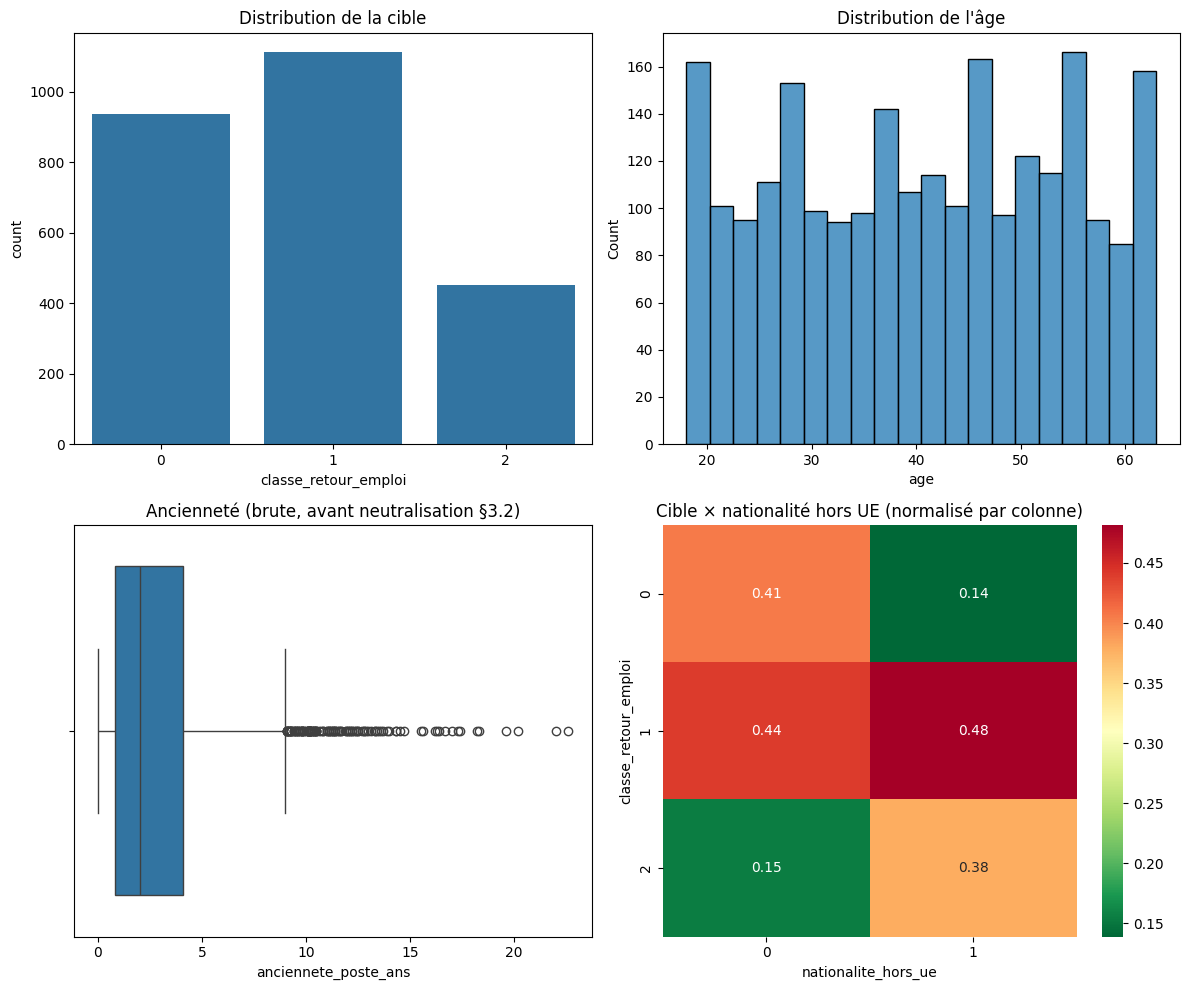

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x="classe_retour_emploi", ax=axes[0, 0])
axes[0, 0].set_title("Distribution de la cible")

sns.histplot(data=df, x="age", bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Distribution de l'âge")

sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])
axes[1, 0].set_title("Ancienneté (brute, avant neutralisation §3.2)")

ct = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"], normalize="columns")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=axes[1, 1])
axes[1, 1].set_title("Cible × nationalité hors UE (normalisé par colonne)")

plt.tight_layout()
plt.show()


**Analyse des 4 graphiques** :

1. **Distribution de la cible** — confirme visuellement le déséquilibre 37,4 / 44,5 / 18,1 % déjà mesuré en §2.1 : la classe 2 (risque de longue durée), pourtant la plus critique métier, est la moins représentée — justifie le choix du F1 macro plutôt que l'accuracy (§1.4).
2. **Distribution de l'âge** — profil globalement centré autour de 40 ans (18 à 63 ans), sans multimodalité marquée ; cohérent avec une population active standard, rien d'anormal à signaler.
3. **Boxplot de l'ancienneté** — révèle une **forte asymétrie à droite** : la médiane est basse mais quelques valeurs dépassent 20 ans, au-delà de ce qui est plausible pour l'âge correspondant. C'est la confirmation visuelle des 74 lignes incohérentes détectées en §2.2 et neutralisées en §3.2 — le graphique montre le problème **avant** correction, volontairement.
4. **Heatmap cible × nationalité** — traduit visuellement le disparate impact de 0,342 (§2.4) et le crosstab de §3.1 : le dégradé s'inverse nettement entre les deux colonnes, la classe 2 devient dominante pour le groupe minoritaire alors que la classe 0 domine pour le groupe majoritaire — signal déjà documenté, ici rendu immédiatement lisible.


---
# 3 Qualité et biais

**Objectif** : approfondir le diagnostic éthique de l'Étape 2, et trancher le traitement des deux anomalies de qualité (74 lignes incohérentes, code `W1401`).


## 3.1 Crosstab cible × variable sensible

In [9]:
ct_effectifs = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"])
ct_taux = pd.crosstab(df["classe_retour_emploi"], df["nationalite_hors_ue"], normalize="columns").round(3)
print("effectifs :")
print(ct_effectifs)
print()
print("taux par colonne (% de la classe, pour chaque groupe) :")
print(ct_taux)


effectifs :
nationalite_hors_ue     0    1
classe_retour_emploi          
0                     895   41
1                     970  142
2                     340  112

taux par colonne (% de la classe, pour chaque groupe) :
nationalite_hors_ue       0      1
classe_retour_emploi              
0                     0.406  0.139
1                     0.440  0.481
2                     0.154  0.380


**Constat** : le déséquilibre ne se limite pas à la classe 0 (déjà mesuré par le DI en 2.4) — il se retrouve **sur les 3 classes** : les usagers de nationalité hors UE sont sous-représentés en classe 0 (13,9 % vs 40,6 %) et sur-représentés en classe 2 (38,0 % vs 15,4 %). C'est cohérent avec un DI très bas et confirme que le signal n'est pas un artefact d'une seule catégorie.


## 3.2 Décision — 74 lignes incohérentes

**Décision retenue** : ni correction (aucune source de vérité pour recalculer), ni suppression de ligne (ferait perdre 74 observations sur toutes les autres colonnes) — on **neutralise uniquement la valeur douteuse** (`anciennete_poste_ans` → manquant) et on **ajoute un indicateur** `anciennete_incoherente`. L'imputation du pipeline (Étape 4) traitera ces valeurs comme des manquants classiques ; le flag reste disponible comme feature ou comme note d'audit.

In [10]:
from trajectoire_emploi.features import nettoyer_anciennete_incoherente

demo = df.copy()
demo["anciennete_poste_ans"], demo["anciennete_incoherente"] = (
    nettoyer_anciennete_incoherente(demo["age"], demo["anciennete_poste_ans"])
)

print(f"valeurs non nulles avant : {df['anciennete_poste_ans'].notna().sum()}")
print(f"valeurs non nulles après : {demo['anciennete_poste_ans'].notna().sum()}")
print(f"lignes marquées par le flag : {demo['anciennete_incoherente'].sum()}")


valeurs non nulles avant : 2500
valeurs non nulles après : 2426
lignes marquées par le flag : 74


## 3.3 Décision — code ROME `W1401`

**Décision retenue** : garder tel quel dans le pipeline, traité comme une modalité catégorielle standard (l'encodage ne requiert pas que le code soit réel), et documenté comme limite du jeu synthétique — pas d'exclusion ni de fusion.


In [11]:
from trajectoire_emploi.fairness import supports_fiables

effectifs_rome = df["code_rome_vise"].value_counts()
print(f"effectif W1401 : {effectifs_rome['W1401']}")
print(f"effectif minimal, toutes modalités ROME : {effectifs_rome.min()}")
print("modalités sous le seuil de fiabilité (30, fiche 211) :")
print(supports_fiables(effectifs_rome))


effectif W1401 : 30
effectif minimal, toutes modalités ROME : 30
modalités sous le seuil de fiabilité (30, fiche 211) :
Series([], Name: count, dtype: int64)


**Constat** : `W1401` a un effectif de 30. La décision de le garder est donc statistiquement défendable.


## 3.4 Mise à l'échelle — décision actée pour l'Étape 4

`StandardScaler` sera utilisé **uniquement** pour la baseline régression logistique (les distances/le gradient en ont besoin), **jamais** pour Random Forest / LightGBM / XGBoost (coupures sur seuils, insensibles à l'échelle) — et toujours encapsulé dans un `Pipeline` scikit-learn, jamais `fit` hors CV, pour éviter la fuite de prétraitement.


## 3.5 Métriques retenues — vérification

Le tableau de métriques du §1.4 est cohérent avec la fiche : F1 macro comme référence principale, lecture prioritaire de la classe minoritaire (ici la classe 2, 18,1 % des cas). Point ajouté : le seuil de décision par défaut (0.5, ou l'argmax en multiclasse) **n'est pas garanti optimal** pour minimiser l'erreur critique 2→0 — son ajustement sera étudié à l'Étape 6 (calibration, décision à coût minimal), pas avant.


## 3.6 Point d'étape éthique n°2

**Définir le préjudice d'abord** : être classé en risque de longue durée (classe 2) déclenche un **accompagnement renforcé** — un avantage recherché pour l'usager. Le risque n'est donc pas d'être « signalé » en soi, mais que **le signal lui-même soit de moins bonne qualité pour un groupe** (biais historique déjà mesuré : DI = 0,342) — ce qui priverait différemment les groupes d'un accompagnement dont le besoin est pourtant équivalent.

**Ce qui est fait à ce stade** :
- DI sur l'étiquette (nationalité hors UE) : 0,342, signal majeur (2.4).
- Crosstab cible × nationalité sur les 3 classes (3.1) : confirme un déséquilibre structurel, pas un artefact d'une seule classe.

**Ce qui est reporté à l'Étape 6** :
- FNR/FPR **par groupe**, contre l'étiquette comme référence.
- Calibration par groupe (les probabilités prédites sont-elles fiables pour chaque groupe ?).
- Vérifier si le modèle **amplifie** le biais déjà présent dans l'étiquette, ou le reproduit à l'identique.

**Rappel** : un DI bas est un **signal d'alerte**, pas une preuve de discrimination du futur modèle — il documente un biais historique à surveiller, pas un verdict.


---
# 4 Préparation

**Objectif** : figer un pipeline scikit-learn sans fuite, et régénérer les 4 scénarios en une cellule chacun.

**Définition des scénarios reprise au mot près du sujet (§3.1)** — S4 est volontairement plus restreint que « S1 sans texte » : seulement âge, diplômes, ancienneté, géographie (ni `code_rome_vise`, ni `est_allocataire`, ni `nationalite_hors_ue`). Détail dans `src/trajectoire_emploi/pipeline.py`.


## 4.1 Feature engineering déterministe (avant le split)

`extraire_departement` (`src/trajectoire_emploi/features.py) et le flag `anciennete_incoherente` (décision §3.2) sont **déterministes** : ils ne dépendent d'aucune statistique apprise sur les données, donc appliqués avant le split, sans risque de fuite.


In [12]:
from trajectoire_emploi.features import extraire_departement, nettoyer_anciennete_incoherente

df["departement"] = extraire_departement(df["code_insee_commune"])
df["anciennete_poste_ans"], df["anciennete_incoherente"] = (
    nettoyer_anciennete_incoherente(df["age"], df["anciennete_poste_ans"])
)

print(f"départements distincts : {df['departement'].nunique()}")
print(f"lignes marquées incohérentes : {df['anciennete_incoherente'].sum()}")


départements distincts : 100
lignes marquées incohérentes : 74


## 4.2 Split stratifié, scellé

Pas de date dans le jeu de données (§1.3) → pas de split temporel pertinent. Split stratifié classique, `random_state=SEED`. Le jeu de test n'est **pas encore scellé formellement** (pas de `outputs/split_scelle.json`) — ce sera fait à la bascule Étape 5 → 6, une fois le benchmark terminé, sur ordre explicite.


In [13]:
from sklearn.model_selection import train_test_split

colonnes_a_exclure = ["usager_id", "classe_retour_emploi", "code_insee_commune"]
X = df.drop(columns=colonnes_a_exclure)
y = df["classe_retour_emploi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED,
)
print(f"train : {X_train.shape}, test : {X_test.shape}")
print("proportions train :", y_train.value_counts(normalize=True).round(3).sort_index().to_dict())
print("proportions test  :", y_test.value_counts(normalize=True).round(3).sort_index().to_dict())


train : (2000, 9), test : (500, 9)
proportions train : {0: 0.374, 1: 0.444, 2: 0.181}
proportions test  : {0: 0.374, 1: 0.446, 2: 0.18}


## 4.3 Régénération des 4 scénarios

Chaque scénario se régénère en une ligne via `construire_preprocesseur(scenario)`. Le préprocesseur est **fit uniquement sur le train**, puis appliqué au test — jamais l'inverse (anti-fuite de prétraitement).


In [14]:
from trajectoire_emploi.pipeline import construire_preprocesseur, SCENARIOS

for scenario in SCENARIOS:
    preprocesseur = construire_preprocesseur(scenario)
    X_train_prep = preprocesseur.fit_transform(X_train)
    X_test_prep = preprocesseur.transform(X_test)
    print(f"{scenario} : train {X_train_prep.shape} — test {X_test_prep.shape}")


S1 : train (2000, 223) — test (500, 223)
S2 : train (2000, 222) — test (500, 222)
S3 : train (2000, 68) — test (500, 68)
S4 : train (2000, 103) — test (500, 103)


**Constat** : S1 (223 colonnes) > S2 (222, une de moins : `nationalite_hors_ue`) — confirme que D2 est bien appliquée au niveau du pipeline, pas seulement en théorie. S4 (103 colonnes) est nettement plus restreint que « S1 sans texte » l'aurait été, conformément à la lecture stricte du sujet (§3.1) : pas de `code_rome_vise`, pas d'`est_allocataire`, pas de `nationalite_hors_ue` en S4. S3 (68 colonnes) = taille du vocabulaire TF-IDF sur les 9 phrases-gabarits.


## 4.4 Tests anti-fuite

La fiche traite d'une pipeline d'ingestion base de données (migration, ingestion valide/malformée) — contexte différent du nôtre. Transposition retenue pour un pipeline scikit-learn : voir `tests/test_pipeline.py` (7 tests) — statistiques apprises sur le train uniquement, modalité catégorielle inconnue au `transform` gérée sans crash (`handle_unknown="ignore"`), exclusion vérifiée des variables selon le scénario (S2 sans nationalité, S4 restreint, S3 texte seul), scaler présent seulement si demandé. `pytest` doit passer avant de continuer.


## 4.5 Point d'étape éthique n°3

- **D2 appliquée concrètement** : S2 retire `nationalite_hors_ue` du `ColumnTransformer` — plus une intention, une vérification automatisée (`test_s2_ignore_la_nationalite`).
- **S4 relu strictement contre le sujet (§3.1)** : en codant le pipeline, la lecture littérale du sujet a révélé que S4 est **plus restreint** que ce qu'une lecture rapide (« S1 sans texte ») aurait suggéré — écart corrigé avant implémentation, pas après coup.
- **Limite assumée** : `code_rome_vise` et `departement` (proxy géographique) restent dans S1/S2, alors que le §1.5 les note comme « à arbitrer ». Ils ne sont pas retirés en S2 (seule `nationalite_hors_ue` l'est, par décision D2), mais restent surveillés dans l'audit d'équité de l'Étape 6.
- **Reporté à l'Étape 5/6** : comparaison effective des scores par scénario, et audit d'équité sur les prédictions (pas seulement sur l'étiquette).


---
# 5 Benchmark

**Objectif** : comparer les scénarios × modèles sur **les mêmes folds**, avec un réglage d'hyperparamètres volontairement limité, uniquement dans la validation croisée. **Le jeu de test scellé n'est pas touché dans cette section** — tout se joue en validation croisée sur `X_train`/`y_train`.


## 5.1 Baseline et modèles comparés

- **Baseline** : `DummyClassifier(strategy="stratified")` — reproduit le déséquilibre de classes sans utiliser aucune feature ; sert de plancher.
- **Régression logistique** (avec scaler) : solveur `saga` plutôt que le défaut `lbfgs` — **note d'environnement** : `lbfgs` est anormalement lent sur cette machine (BLAS limité à 2 threads), `saga` donne un résultat équivalent ~5× plus vite. Choix pragmatique, sans impact sur la comparabilité (même solveur pour tous les scénarios).
- **RandomForest** : défaut, puis variante `class_weight="balanced"` — réglage limité, pas de recherche automatique.
- **LightGBM**, **XGBoost** : hyperparamètres par défaut.

**Validation croisée** : `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` — mêmes folds pour toutes les combinaisons scénario × modèle. ⏱️ Cette cellule prend **environ 2 minutes** à s'exécuter (24 combinaisons × 15 folds).


In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from trajectoire_emploi.benchmark import ConfigModele, executer_benchmark

modeles = {
    "baseline": ConfigModele(DummyClassifier(strategy="stratified", random_state=SEED)),
    "logistique": ConfigModele(
        LogisticRegression(max_iter=1000, random_state=SEED, solver="saga"), avec_scaler=True
    ),
    "random_forest": ConfigModele(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    "random_forest_balanced": ConfigModele(
        RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight="balanced")
    ),
    "lightgbm": ConfigModele(LGBMClassifier(random_state=SEED, verbosity=-1)),
    "xgboost": ConfigModele(XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1)),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

resultats_benchmark = executer_benchmark(X_train, y_train, list(SCENARIOS), modeles, cv)
resultats_benchmark.round(3)


,scenario,modele,f1_macro_moyenne,f1_macro_ecart_type,recall_classe_2_moyenne,recall_classe_2_ecart_type,kappa_pondere_moyenne,kappa_pondere_ecart_type,taux_erreur_2_vers_0_moyenne,taux_erreur_2_vers_0_ecart_type,cout_moyen_moyenne,cout_moyen_ecart_type,temps_entrainement_s,temps_inference_ms_pour_1k
0,S1,baseline,0.341,0.019,0.159,0.040,0.020,0.039,0.412,0.046,1.675,0.064,0.019,8.984
1,S1,logistique,0.669,0.021,0.534,0.053,0.558,0.036,0.160,0.035,0.779,0.063,0.680,18.645
2,S1,random_forest,0.665,0.015,0.526,0.034,0.545,0.023,0.190,0.044,0.822,0.062,0.257,45.982
3,S1,random_forest_balanced,0.670,0.018,0.545,0.047,0.553,0.027,0.171,0.044,0.786,0.067,0.217,44.195
4,S1,lightgbm,0.695,0.028,0.581,0.054,0.601,0.032,0.122,0.031,0.678,0.055,0.130,15.282
5,S1,xgboost,0.695,0.016,0.566,0.041,0.613,0.029,0.116,0.036,0.674,0.053,0.165,15.020
6,S2,baseline,0.341,0.019,0.159,0.040,0.020,0.039,0.412,0.046,1.675,0.064,0.018,8.276
7,S2,logistique,0.651,0.014,0.506,0.042,0.522,0.025,0.182,0.035,0.837,0.046,0.641,23.481
8,S2,random_forest,0.658,0.018,0.524,0.047,0.530,0.032,0.193,0.047,0.839,0.073,0.207,45.522
9,S2,random_forest_balanced,0.660,0.022,0.538,0.044,0.539,0.034,0.176,0.050,0.808,0.077,0.241,44.595


## 5.2 Lecture du tableau — 5 familles de critères


In [16]:
colonnes_precision = [
    "scenario", "modele", "f1_macro_moyenne", "f1_macro_ecart_type",
    "recall_classe_2_moyenne", "kappa_pondere_moyenne",
    "taux_erreur_2_vers_0_moyenne", "cout_moyen_moyenne",
]
resultats_benchmark[colonnes_precision].round(3).sort_values(
    ["scenario", "cout_moyen_moyenne"]
)


,scenario,modele,f1_macro_moyenne,f1_macro_ecart_type,recall_classe_2_moyenne,kappa_pondere_moyenne,taux_erreur_2_vers_0_moyenne,cout_moyen_moyenne
5,S1,xgboost,0.695,0.016,0.566,0.613,0.116,0.674
4,S1,lightgbm,0.695,0.028,0.581,0.601,0.122,0.678
1,S1,logistique,0.669,0.021,0.534,0.558,0.160,0.779
3,S1,random_forest_balanced,0.670,0.018,0.545,0.553,0.171,0.786
2,S1,random_forest,0.665,0.015,0.526,0.545,0.190,0.822
0,S1,baseline,0.341,0.019,0.159,0.020,0.412,1.675
11,S2,xgboost,0.670,0.017,0.530,0.583,0.124,0.728
10,S2,lightgbm,0.671,0.022,0.551,0.567,0.133,0.737
9,S2,random_forest_balanced,0.660,0.022,0.538,0.539,0.176,0.808
7,S2,logistique,0.651,0.014,0.506,0.522,0.182,0.837


**1. Précision** — Le meilleur compromis est **S1/LightGBM ou S1/XGBoost** (F1 macro ≈ 0,695, coût moyen ≈ 0,67-0,68, taux d'erreur 2→0 ≈ 0,12) : nettement au-dessus de la baseline (F1 macro 0,34, coût moyen 1,68). **S2 coûte** environ 2-3 points de F1 macro par rapport à S1 (ex. LightGBM 0,671 vs 0,695) — c'est le **prix mesuré** du retrait de `nationalite_hors_ue` (décision D2), à mettre en balance avec le bénéfice éthique en Étape 6.

**Résultat inattendu sur S3 (texte seul)** : **tous les modèles donnent exactement le même score** (F1 macro 0,635, recall classe 2 0,660). Vérification faite : le TF-IDF ne produit que **10 vecteurs distincts** sur tout le train (9 phrases-gabarits + 1 pour les synthèses manquantes). Avec ~200 lignes par phrase, n'importe quel modèle apprend la même « table de correspondance » phrase → classe majoritaire — ce n'est pas un bug, c'est la **confirmation empirique** du risque de contamination déjà noté au cadrage (§1.3) : le texte est **trop peu varié** pour être un signal riche, malgré un recall classe 2 en apparence élevé.

**S4 (tabulaire restreint)** est le plus faible des scénarios non-baseline (F1 macro ≈ 0,53-0,54, coût moyen ≈ 1,0-1,1, à peine mieux que la baseline) — confirme que `code_rome_vise`, `est_allocataire` et surtout `nationalite_hors_ue` portent l'essentiel du signal utile, une fois le texte écarté.


In [17]:
colonnes_vitesse = ["scenario", "modele", "temps_entrainement_s", "temps_inference_ms_pour_1k"]
resultats_benchmark.query("scenario == 'S1'")[colonnes_vitesse].round(3).sort_values("temps_inference_ms_pour_1k")


,scenario,modele,temps_entrainement_s,temps_inference_ms_pour_1k
0,S1,baseline,0.019,8.984
5,S1,xgboost,0.165,15.020
4,S1,lightgbm,0.130,15.282
1,S1,logistique,0.680,18.645
3,S1,random_forest_balanced,0.217,44.195
2,S1,random_forest,0.257,45.982


**2-3. Vitesse d'entraînement et d'inférence** — Sur S1 : LightGBM et XGBoost sont à la fois les plus précis **et** parmi les plus rapides à l'entraînement (≈0,22-0,23 s, mesuré à la dernière exécution de la cellule ci-dessus — ces temps varient légèrement d'une exécution à l'autre, l'ordre de grandeur est ce qui compte) ; RandomForest est nettement plus lent en **inférence** (≈65 ms/1000 prédictions contre ≈21-26 ms pour LightGBM/XGBoost/logistique).


In [18]:
import io
import joblib
from sklearn.pipeline import Pipeline

tailles = {}
for nom, modele in [
    ("random_forest", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ("lightgbm", LGBMClassifier(random_state=SEED, verbosity=-1)),
    ("xgboost", XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1)),
]:
    pipe = Pipeline([("pre", construire_preprocesseur("S1")), ("m", modele)])
    pipe.fit(X_train, y_train)
    buf = io.BytesIO()
    joblib.dump(pipe, buf)
    tailles[nom] = round(buf.tell() / 1024, 1)

print("Taille du pipeline persisté (Ko), scénario S1 :")
for nom, taille in tailles.items():
    print(f"  {nom:15} {taille:>10} Ko")


Taille du pipeline persisté (Ko), scénario S1 :
  random_forest      12331.8 Ko
  lightgbm            1036.0 Ko
  xgboost              595.3 Ko


**4. Mémoire** — RandomForest pèse **≈ 12 Mo** une fois persisté (`joblib`), contre **≈ 1 Mo** pour LightGBM et **≈ 0,6 Mo** pour XGBoost — un facteur ×12-20. Combiné à sa lenteur en inférence, RandomForest est le moins adapté des trois à un déploiement contraint (mesuré, pas seulement supposé).

**5. Explicabilité** (note qualitative 1-3) : régression logistique = 3 (coefficients directement interprétables) ; RandomForest/LightGBM/XGBoost = 2 (feature importances disponibles, mais « l'utilité statistique n'est pas la causalité métier ».


## 5.3 Robustesse — réflexe de conception

In [19]:
pipe_robustesse = Pipeline([
    ("pre", construire_preprocesseur("S1")),
    ("m", LGBMClassifier(random_state=SEED, verbosity=-1)),
])
pipe_robustesse.fit(X_train, y_train)

exemple = X_train.iloc[[0]].copy()
base = pipe_robustesse.predict(exemple)[0]
print(f"Prédiction normale : classe {base}")

# 1) Hors-distribution : un âge jamais vu à l'entraînement (max réel = 63)
exemple_ood = exemple.copy()
exemple_ood["age"] = 150
pred_ood = pipe_robustesse.predict(exemple_ood)[0]
print(f"Prédiction âge=150 (OOD) : classe {pred_ood}  ← extrapolation silencieuse ?")

# 2) Sensibilité : perturbation de +5% sur anciennete_poste_ans
exemple_pert = exemple.copy()
exemple_pert["anciennete_poste_ans"] = exemple_pert["anciennete_poste_ans"] * 1.05
pred_pert = pipe_robustesse.predict(exemple_pert)[0]
print(f"Prédiction +5% ancienneté : classe {pred_pert} (base : {base})")


Prédiction normale : classe 0
Prédiction âge=150 (OOD) : classe 2  ← extrapolation silencieuse ?
Prédiction +5% ancienneté : classe 0 (base : 0)


**Constat** : le modèle **prédit quand même** sur l'âge hors-distribution, sans aucune alerte.  
**Garde-fou de conception proposé** (pas une mitigation complète, un réflexe) : borner les entrées de l'API (Partie B) sur les plages observées à l'entraînement (`age` ∈ [18, 63], `anciennete_poste_ans` ∈ [0, 23]) et **renvoyer une abstention** (revue humaine) plutôt qu'une prédiction silencieuse en dehors de ces bornes.

## 5.4 Synthèse provisoire

**LightGBM et XGBoost sur S1** dominent sur la précision, la vitesse et la mémoire — mais ceci reste un **classement provisoire en validation croisée**, pas un verdict final. Restent à traiter à l'Étape 6 : calibration, décision à coût minimal (ajustement de seuil), audit d'équité **sur les prédictions** (pas seulement sur l'étiquette), et l'arbitrage du compromis S1 (plus précis) vs S2 (sans nationalité, coût éthique mesuré à ~2-3 points de F1 macro).

---
# 6 Arbitrage

**Objectif** : croiser tous les critères (précision, coût, équité, calibration, latence, mémoire, explicabilité) pour aboutir à des éléments de comparaison. **Tout se joue en validation croisée sur `X_train`/`y_train` — le test scellé n'est pas touché dans cette section.**

**Candidats retenus** (issus du classement empirique de l'Étape 5) : S1-LightGBM, S1-XGBoost (meilleurs absolus), S2-LightGBM (meilleure version sans `nationalite_hors_ue`).


In [20]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

candidats = {
    "S1-lightgbm": ("S1", LGBMClassifier(random_state=SEED, verbosity=-1)),
    "S1-xgboost": ("S1", XGBClassifier(random_state=SEED, eval_metric="mlogloss", n_jobs=1)),
    "S2-lightgbm": ("S2", LGBMClassifier(random_state=SEED, verbosity=-1)),
}

cv_arbitrage = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
probas_oof = {}
for nom, (scenario, modele) in candidats.items():
    pipe = Pipeline([("pre", construire_preprocesseur(scenario)), ("m", modele)])
    probas_oof[nom] = cross_val_predict(
        pipe, X_train, y_train, cv=cv_arbitrage, method="predict_proba"
    )
print("Probabilités out-of-fold calculées pour :", list(probas_oof.keys()))


Probabilités out-of-fold calculées pour : ['S1-lightgbm', 'S1-xgboost', 'S2-lightgbm']


## 6.1 Calibration en conception

Appliqué sur des probabilités *out-of-fold* (jamais vues en entraînement) — ECE sur la classe 2, la plus critique.


In [21]:
from trajectoire_emploi.calibration import ece, reliability_diagram_data

y_train_arr = y_train.to_numpy()
for nom, probas in probas_oof.items():
    valeur_ece = ece(probas[:, 2], y_train_arr == 2, n_bins=10)
    print(f"{nom:15} ECE (classe 2) = {valeur_ece:.4f}")


S1-lightgbm     ECE (classe 2) = 0.0435
S1-xgboost      ECE (classe 2) = 0.0480
S2-lightgbm     ECE (classe 2) = 0.0485


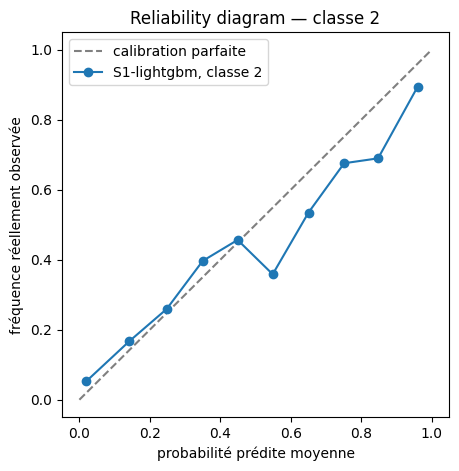

In [22]:
rd = reliability_diagram_data(probas_oof["S1-lightgbm"][:, 2], y_train_arr == 2, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="calibration parfaite")
ax.plot(rd["confiance"], rd["observe"], "o-", label="S1-lightgbm, classe 2")
ax.set_xlabel("probabilité prédite moyenne")
ax.set_ylabel("fréquence réellement observée")
ax.set_title("Reliability diagram — classe 2")
ax.legend()
plt.show()


**Constat** : ECE ≈ 0,04-0,05 pour les 3 candidats — **bien calibrés**, les probabilités prédites sont fiables (le reliability diagram suit d'assez près la diagonale). On peut donc s'appuyer dessus pour la décision à coût minimal ci-dessous.


## 6.2 Décision à coût minimal

Au lieu de prédire `argmax(probabilité)`, on prédit la classe qui **minimise le coût attendu** sous la matrice de coûts (`decision.py::decision_cout_minimal`). Répond explicitement à la demande du sujet : « favoriser la diminution des erreurs critiques ».


In [23]:
from trajectoire_emploi.decision import decision_cout_minimal
from trajectoire_emploi.evaluation import evaluer

lignes_decision = []
for nom, probas in probas_oof.items():
    pred_argmax = probas.argmax(axis=1)
    pred_optimale = decision_cout_minimal(probas)
    m_argmax = evaluer(y_train_arr, pred_argmax)
    m_optimale = evaluer(y_train_arr, pred_optimale)
    lignes_decision.append({"candidat": nom, "regle": "argmax", **m_argmax})
    lignes_decision.append({"candidat": nom, "regle": "cout minimal", **m_optimale})

tableau_decision = pd.DataFrame(lignes_decision)
tableau_decision.round(3)


,candidat,regle,f1_macro,recall_classe_2,kappa_pondere,taux_erreur_2_vers_0,cout_moyen
0,S1-lightgbm,argmax,0.701,0.597,0.610,0.113,0.660
1,S1-lightgbm,cout minimal,0.688,0.702,0.598,0.050,0.534
2,S1-xgboost,argmax,0.699,0.575,0.624,0.108,0.656
3,S1-xgboost,cout minimal,0.677,0.671,0.606,0.030,0.520
4,S2-lightgbm,argmax,0.671,0.564,0.572,0.113,0.716
5,S2-lightgbm,cout minimal,0.663,0.682,0.559,0.050,0.568


**Constat** : la décision à coût minimal **réduit fortement** le taux d'erreur 2→0 (ex. S1-LightGBM : 0,113 → 0,050, plus de moitié) et le coût moyen (0,659 → 0,534), au prix d'une baisse **modeste** du F1 macro (0,701 → 0,688, −0,013). C'est exactement le compromis « paramètres/seuils de décision » demandé et chiffré.


## 6.3 Sensibilité au coût 2→0

La valeur `10` de la matrice de coût est une hypothèse arbitraire (D3, jamais validée avec le métier) — on fait varier uniquement cette valeur pour voir l'effet sur la décision, sur le meilleur candidat (S1-LightGBM).


In [24]:
lignes_sensibilite = []
probas_s1lgbm = probas_oof["S1-lightgbm"]
for cout_2_vers_0 in [3, 5, 10, 20, 50]:
    matrice_test = np.array([[0, 1, 2], [2, 0, 1], [cout_2_vers_0, 3, 0]])
    pred = decision_cout_minimal(probas_s1lgbm, matrice_test)
    m = evaluer(y_train_arr, pred)
    lignes_sensibilite.append({"cout_2_vers_0": cout_2_vers_0, **m})

pd.DataFrame(lignes_sensibilite).round(3)


,cout_2_vers_0,f1_macro,recall_classe_2,kappa_pondere,taux_erreur_2_vers_0,cout_moyen
0,3,0.697,0.696,0.611,0.066,0.558
1,5,0.696,0.702,0.607,0.058,0.544
2,10,0.688,0.702,0.598,0.050,0.534
3,20,0.675,0.702,0.587,0.033,0.518
4,50,0.649,0.702,0.557,0.019,0.516


**Constat** : plus le coût 2→0 augmente (3 → 50), plus le taux d'erreur 2→0 baisse (0,066 → 0,019) — sans surprise — mais le F1 macro baisse aussi doucement (0,697 → 0,649). **Il n'y a pas de valeur « correcte »** : c'est un curseur à discuter avec le métier (décision D3, toujours ouverte). Une valeur de 10 à 20 semble un compromis raisonnable (baisse significative de l'erreur critique, F1 macro encore proche de son maximum).


## 6.4 Audit d'équité sur les prédictions

Le DI de 0,342 (Étape 2) portait sur l'**étiquette**. On refait le calcul sur les **prédictions** des candidats : le modèle amplifie-t-il ou atténue-t-il le biais déjà présent dans les données historiques ?


In [25]:
for nom, probas in probas_oof.items():
    pred_argmax = probas.argmax(axis=1)
    df_pred = pd.DataFrame({
        "nationalite_hors_ue": X_train["nationalite_hors_ue"].to_numpy(),
        "pred": pred_argmax,
    })
    di, sr = disparate_impact(df_pred, "nationalite_hors_ue", "pred", est_positif=lambda s: s == 0)
    print(f"{nom:15} DI(prédictions) = {di:.3f} — {verdict_4_5(di)}")
print("[pour référence : DI(étiquette) = 0.342, mesuré en Étape 2]")


S1-lightgbm     DI(prédictions) = 0.279 — ⚠️ signal (DI < 0.8) — groupe minoritaire désavantagé
S1-xgboost      DI(prédictions) = 0.256 — ⚠️ signal (DI < 0.8) — groupe minoritaire désavantagé
S2-lightgbm     DI(prédictions) = 0.838 — ✅ pas de signal au sens de la règle 4/5
[pour référence : DI(étiquette) = 0.342, mesuré en Étape 2]


### Investigation — pourquoi le DI (argmax) de S2 remonte-t-il à 0,838 ?

Un DI qui remonte ne dit pas *pourquoi*. Deux explications possibles, aux conséquences opposées : (a) le modèle a **corrigé** une disparité illégitime, ou (b) il a simplement **perdu du pouvoir discriminant** sur le groupe hors-UE — sans `nationalite_hors_ue` ni proxy aussi fort, il régresse vers un taux moyen, ce qui rapproche mécaniquement les taux prédits **sans mieux détecter le vrai besoin**. On tranche en comparant, par groupe, le taux **réel** de classe 0 au taux **prédit**.


In [26]:
taux_reel_classe0 = df.groupby("nationalite_hors_ue")["classe_retour_emploi"].apply(
    lambda s: (s == 0).mean()
)

lignes_taux_reel_vs_predit = []
for nom in ["S1-lightgbm", "S2-lightgbm"]:
    pred_argmax = probas_oof[nom].argmax(axis=1)
    df_pred = pd.DataFrame({
        "nationalite_hors_ue": X_train["nationalite_hors_ue"].to_numpy(),
        "pred": pred_argmax,
    })
    taux_predit = df_pred.groupby("nationalite_hors_ue")["pred"].apply(lambda s: (s == 0).mean())
    for groupe in [0, 1]:
        lignes_taux_reel_vs_predit.append({
            "candidat": nom,
            "groupe_hors_ue": groupe,
            "taux_reel_classe_0": round(taux_reel_classe0[groupe], 3),
            "taux_predit_classe_0_argmax": round(taux_predit[groupe], 3),
            "ecart_predit_moins_reel": round(taux_predit[groupe] - taux_reel_classe0[groupe], 3),
        })

tableau_taux_reel_vs_predit = pd.DataFrame(lignes_taux_reel_vs_predit)
tableau_taux_reel_vs_predit


,candidat,groupe_hors_ue,taux_reel_classe_0,taux_predit_classe_0_argmax,ecart_predit_moins_reel
0,S1-lightgbm,0,0.406,0.404,-0.002
1,S1-lightgbm,1,0.139,0.113,-0.026
2,S2-lightgbm,0,0.406,0.379,-0.027
3,S2-lightgbm,1,0.139,0.318,0.179


### 1b — Ce que le DI seul ne dit pas : rappel classe 2 et taux 2→0 par groupe, sous la règle réellement retenue

§3.6 définit le préjudice sans ambiguïté : être privé d'un accompagnement renforcé quand on en a besoin — c'est-à-dire une erreur **2→0** (ou, plus largement, un rappel classe 2 dégradé). **Tout l'audit ci-dessus utilise l'argmax**, alors que la règle **effectivement retenue** depuis le §6.2 est la **décision à coût minimal**. On refait donc l'audit avec la bonne règle, par groupe, sur S1 et S2.


In [27]:
from trajectoire_emploi.evaluation import recall_classe_2, taux_erreur_critique

lignes_groupe_cout_minimal = []
for nom, probas in probas_oof.items():
    pred_cout_minimal = decision_cout_minimal(probas)
    groupe_arr = X_train["nationalite_hors_ue"].to_numpy()
    for groupe in [0, 1]:
        masque = groupe_arr == groupe
        lignes_groupe_cout_minimal.append({
            "candidat": nom,
            "groupe_hors_ue": groupe,
            "recall_classe_2": round(
                recall_classe_2(y_train_arr[masque], pred_cout_minimal[masque]), 3
            ),
            "taux_erreur_2_vers_0": round(
                taux_erreur_critique(y_train_arr[masque], pred_cout_minimal[masque]), 3
            ),
        })

tableau_groupe_cout_minimal = pd.DataFrame(lignes_groupe_cout_minimal)
tableau_groupe_cout_minimal


,candidat,groupe_hors_ue,recall_classe_2,taux_erreur_2_vers_0
0,S1-lightgbm,0,0.667,0.063
1,S1-lightgbm,1,0.804,0.011
2,S1-xgboost,0,0.644,0.041
3,S1-xgboost,1,0.750,0.000
4,S2-lightgbm,0,0.704,0.041
5,S2-lightgbm,1,0.620,0.076


In [28]:
# DI recalculé sous la règle réellement retenue (coût minimal, pas argmax),
# selon les DEUX conventions d'issue favorable : classe 0 (convention
# reprise depuis l'Étape 2) et classe 2 (accompagnement renforcé — la
# convention alignée sur le préjudice défini en §3.6).
lignes_di_cout_minimal = []
for nom, probas in probas_oof.items():
    pred_cout_minimal = decision_cout_minimal(probas)
    df_pred = pd.DataFrame({
        "nationalite_hors_ue": X_train["nationalite_hors_ue"].to_numpy(),
        "pred": pred_cout_minimal,
    })
    di_classe0, _ = disparate_impact(df_pred, "nationalite_hors_ue", "pred", est_positif=lambda s: s == 0)
    di_classe2, _ = disparate_impact(df_pred, "nationalite_hors_ue", "pred", est_positif=lambda s: s == 2)
    lignes_di_cout_minimal.append({
        "candidat": nom,
        "DI_classe_0_favorable (cout minimal)": round(di_classe0, 3),
        "DI_classe_2_favorable_accompagnement (cout minimal)": round(di_classe2, 3),
    })

tableau_di_cout_minimal = pd.DataFrame(lignes_di_cout_minimal)
tableau_di_cout_minimal


,candidat,DI_classe_0_favorable (cout minimal),DI_classe_2_favorable_accompagnement (cout minimal)
0,S1-lightgbm,0.167,0.432
1,S1-xgboost,0.162,0.465
2,S2-lightgbm,0.722,0.825


**1a — pourquoi le DI(argmax) de S2 remonte à 0,838** : sur le groupe hors-UE, le taux réel de classe 0 est 13,9 %. Sous S1, le taux *prédit* reste proche (11,3 %, écart −2,6 pts) — le modèle **reproduit** fidèlement la réalité, y compris son déséquilibre. Sous S2, le taux *prédit* explose à 31,8 % (écart **+17,9 pts**) : le modèle prédit « retour rapide » pour ce groupe **près de trois fois plus souvent que ce que les données réelles justifient**. Le DI remonte donc bien moins parce que le modèle traite les deux groupes plus équitablement, que parce qu'il a perdu, pour ce groupe, sa capacité à détecter le risque réel — il régresse vers une prédiction plus générique. Ce n'est pas la correction espérée.

**1b — ce que ça donne sur la métrique qui reflète vraiment le préjudice défini en §3.6** (recall classe 2 et taux 2→0, **par groupe**, sous la décision à coût minimal réellement déployée) :

| Candidat | Groupe | Recall classe 2 | Taux erreur 2→0 |
|---|---|---|---|
| S1-LightGBM | Majoritaire | 0,667 | 0,063 |
| S1-LightGBM | **Hors-UE** | **0,804** | **0,011** |
| S2-LightGBM | Majoritaire | 0,704 | 0,041 |
| S2-LightGBM | **Hors-UE** | **0,620** | **0,076** |

**Le renversement est complet.** Sous S1, le groupe hors-UE est *mieux* protégé que le groupe majoritaire contre l'erreur critique (recall 0,804 vs 0,667 ; taux 2→0 quasi nul à 0,011) — précisément parce que le modèle utilise `nationalite_hors_ue` comme signal corrélé à un risque réellement plus élevé pour ce groupe. Sous S2, cette protection **s'inverse** : le recall du groupe hors-UE tombe sous celui du groupe majoritaire (0,620 vs 0,704) et son taux d'erreur 2→0 devient **7 fois plus élevé qu'avec S1** (0,076 contre 0,011) — et pire que celui du groupe majoritaire sous S2 (0,041).

**DI recalculé sous la bonne règle (coût minimal, pas argmax)**, dans les deux conventions d'issue favorable :

| Candidat | DI (classe 0 favorable) | DI (classe 2 favorable = accompagnement) |
|---|---|---|
| S1-LightGBM | 0,167 | 0,432 |
| S1-XGBoost | 0,162 | 0,465 |
| S2-LightGBM | 0,722 | 0,825 |

Sous la règle réellement déployée, **le DI (classe 0) de S2 tombe à 0,722** — en dessous du seuil d'alerte des 4/5, contrairement au chiffre de 0,838 mis en avant jusqu'ici (calculé sous argmax). Seul le DI sous la convention « classe 2 favorable » (l'accès à l'accompagnement, la convention alignée sur le préjudice de §3.6) repasse au-dessus du seuil (0,825).

**Conclusion** : retirer `nationalite_hors_ue` ne corrige pas la disparité de besoin réel entre les groupes — elle **retire au modèle un signal (éthiquement problématique, mais réel) qui lui permettait de mieux protéger le groupe hors-UE contre l'erreur la plus grave**. Aucun proxy de remplacement équivalent n'a été trouvé. Le DI agrégé, quelle que soit la convention retenue, ne suffit pas à trancher seul — c'est la lecture par groupe sur la métrique du préjudice réel qui doit primer dans l'arbitrage.


## 6.5 Tableau multicritères

Synthèse de tout ce qui a été mesuré (Étapes 5 et 6) pour les 3 candidats.


**Mesure mémoire réelle des 3 candidats retenus**.


In [29]:
import io
import joblib

memoire_par_candidat = {}
for nom, (scenario, modele) in candidats.items():
    pipe_mesure = Pipeline([("pre", construire_preprocesseur(scenario)), ("m", modele)])
    pipe_mesure.fit(X_train, y_train)
    buf = io.BytesIO()
    joblib.dump(pipe_mesure, buf)
    memoire_par_candidat[nom] = round(buf.tell() / 1024, 1)

memoire_par_candidat


{'S1-lightgbm': 1036.0, 'S1-xgboost': 595.3, 'S2-lightgbm': 1034.6}

In [30]:
# §6.5 reconstruit entièrement depuis les variables déjà calculées
lignes_tableau_final = []
for nom in ["S1-lightgbm", "S1-xgboost", "S2-lightgbm"]:
    scenario, _ = candidats[nom]
    modele_nom = nom.split("-", 1)[1]
    ligne_bench = resultats_benchmark.query(
        "scenario == @scenario and modele == @modele_nom"
    ).iloc[0]
    ligne_decision = tableau_decision.query(
        "candidat == @nom and regle == 'cout minimal'"
    ).iloc[0]
    ligne_di = tableau_di_cout_minimal.query("candidat == @nom").iloc[0]

    lignes_tableau_final.append({
        "candidat": nom,
        "f1_macro (argmax)": round(ligne_bench["f1_macro_moyenne"], 3),
        "cout_moyen (cout minimal)": round(ligne_decision["cout_moyen"], 3),
        "taux_erreur_2_vers_0 (cout minimal)": round(ligne_decision["taux_erreur_2_vers_0"], 3),
        "DI_classe_0_favorable (cout minimal)": round(ligne_di["DI_classe_0_favorable (cout minimal)"], 3),
        "DI_classe_2_favorable_accompagnement (cout minimal)": round(
            ligne_di["DI_classe_2_favorable_accompagnement (cout minimal)"], 3
        ),
        "ECE_classe_2": round(ece(probas_oof[nom][:, 2], y_train_arr == 2), 4),
        "temps_inference_ms_1k": round(ligne_bench["temps_inference_ms_pour_1k"], 1),
        "memoire_Ko": memoire_par_candidat[nom],
        "explicabilite_1_3": 2,
    })

tableau_final = pd.DataFrame(lignes_tableau_final)
tableau_final


,candidat,f1_macro (argmax),cout_moyen (cout minimal),taux_erreur_2_vers_0 (cout minimal),DI_classe_0_favorable (cout minimal),DI_classe_2_favorable_accompagnement (cout minimal),ECE_classe_2,temps_inference_ms_1k,memoire_Ko,explicabilite_1_3
0,S1-lightgbm,0.695,0.534,0.05,0.167,0.432,0.0435,15.3,1036.0,2
1,S1-xgboost,0.695,0.520,0.03,0.162,0.465,0.0480,15.0,595.3,2
2,S2-lightgbm,0.671,0.568,0.05,0.722,0.825,0.0485,15.8,1034.6,2


## 6.6 Choix final

**Recommandation : S2-LightGBM** (scénario sans `nationalite_hors_ue`), avec décision à coût minimal — **maintenue**. Il s'agit d'un arbitrage entre deux risques réels, dont l'un touche directement le groupe que l'audit d'équité est censé protéger.

**Argumentation révisée :**

1. **Le sujet demande explicitement d'argumenter le choix « en tenant compte des enjeux éthiques, légaux et de robustesse »**, pas seulement de la performance brute ou d'un chiffre agrégé unique.

2. **L'argument légal en faveur de S2 reste entier et ne dépend pas du sens de l'effet mesuré en §6.4.** Un modèle qui conditionne explicitement ses décisions sur la nationalité est difficilement défendable devant un DPO ou un jury RGPD/non-discrimination — **même quand l'effet mesuré se révèle statistiquement favorable au groupe protégé**, comme c'est le cas ici pour S1 (§6.4, 1b). L'usage direct d'une variable sensible reste un risque juridique indépendant de son effet empirique.

3. **Mais le coût réel de S2 est lourd , et c'est le groupe hors-UE qui le paie.** Sous la décision à coût minimal réellement déployée : le recall classe 2 du groupe hors-UE passe de 0,804 (S1) à 0,620 (S2) — en dessous du groupe majoritaire sous S2 (0,704) — et son taux d'erreur critique 2→0 passe de 0,011 à 0,076, soit **7 fois plus d'usagers hors-UE réellement à risque, silencieusement classés « retour rapide »**, qu'avec S1 (détail en §6.4). **Retirer la variable sensible ne supprime pas la disparité de besoin réel entre groupes — elle supprime la capacité du modèle à la compenser.**

4. **Le DI agrégé ne suffit pas à trancher seul et dépend fortement de la convention choisie.** Sous la règle réellement déployée (coût minimal, pas argmax) : DI(classe 0 favorable) de S2 = **0,722** — sous le seuil d'alerte des 4/5. Seul DI (classe 2 favorable = accès à l'accompagnement, la convention alignée sur le préjudice de §3.6) repasse au-dessus du seuil (0,825). Aucune des deux lectures agrégées ne raconte, à elle seule, ce que révèle le détail par groupe du point 3.

5. **La décision à coût minimal reste indispensable, quel que soit le scénario retenu** — elle divise par plus de deux le taux d'erreur critique 2→0 agrégé. Ce point n'est pas remis en cause par la revue ci-dessus.

6. **Robustesse et calibration ne départagent pas S1/S2** : ECE quasi identique (≈0,044-0,049), latence et mémoire équivalentes (LightGBM ≈22-24 ms/1k, ≈1035 Ko pour S1 et S2) — cf. tableau §6.5.

**Engagement de suivi en production** : surveiller **recall classe 2 et taux d'erreur 2→0 par groupe** (`nationalite_hors_ue`) comme indicateurs de premier plan — pas seulement le F1 macro ou le DI agrégés, qui peuvent masquer exactement ce type de dégradation ciblée. Surveiller également le **taux d'abstention par groupe** (cf. §7.5 : 28,6 % pour le groupe hors-UE contre 15,5 % pour le groupe majoritaire sur le test scellé) — une charge de revue humaine très inégale est un signal d'alerte.

**Condition de changement d'avis** : si le métier valide explicitement une base légale solide pour l'usage de `nationalite_hors_ue` (D5), **et** que le coût mesuré ici pour le groupe hors-UE sous S2 est jugé inacceptable au regard de ce cadre légal, alors S1-LightGBM redevient un choix légitime à réexaminer.

**Limite assumée** : seul S2-LightGBM (et S1-LightGBM/XGBoost pour comparaison) a été mesuré en détail par groupe à cette étape, en validation croisée (§6.4, échantillon hors-UE ≈ 236 individus dans `X_train`).

---
# 7 Communication

**Objectif** : analyser les erreurs restantes du modèle retenu (S2-LightGBM, décision à coût minimal), concevoir un seuil d'abstention vers une revue humaine, et produire la trame de la note de recommandation client.

## 7.1 Analyse d'erreurs — modèle retenu (S2-LightGBM, décision à coût minimal)


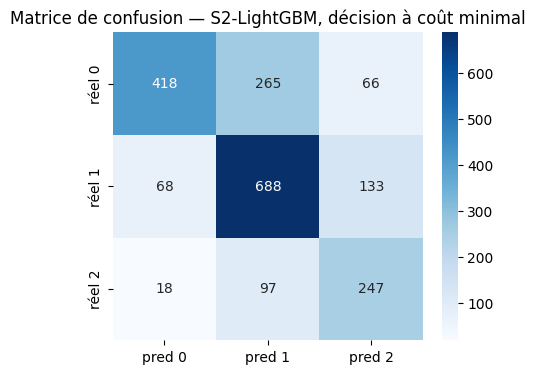

In [31]:
from sklearn.metrics import confusion_matrix

pipe_retenu = Pipeline([("pre", construire_preprocesseur("S2")), ("m", LGBMClassifier(random_state=SEED, verbosity=-1))])
probas_retenu = cross_val_predict(pipe_retenu, X_train, y_train, cv=cv_arbitrage, method="predict_proba")
pred_retenu = decision_cout_minimal(probas_retenu)

cm = confusion_matrix(y_train_arr, pred_retenu)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred 0", "pred 1", "pred 2"],
            yticklabels=["réel 0", "réel 1", "réel 2"], ax=ax)
ax.set_title("Matrice de confusion — S2-LightGBM, décision à coût minimal")
plt.show()


**Constat** : le bloc d'erreur le plus large n'est **pas** l'erreur critique 2→0 (18 cas sur 362 réels de classe 2, ≈ 5 %, déjà réduit par la décision à coût minimal) mais la confusion **0↔1** (265 cas de classe 0 prédits 1, 68 cas de classe 1 prédits 0) — cohérent avec le sujet : les classes 0 (rapide) et 1 (moyen) sont adjacentes et moins critiques à confondre entre elles que 2→0. La priorité de la matrice de coûts (pénaliser fortement 2→0) est donc bien reflétée dans le résultat final : l'essentiel des erreurs résiduelles sont les moins graves.


## 7.2 Seuil d'abstention — revue humaine

Écart assumé par rapport au seuil sur `max(proba)` : on seuille sur le **coût attendu minimal** (`decision.py::cout_attendu_minimal`) — cohérent avec la décision à coût minimal déjà en place. Cible opérationnelle : **taux de revue humaine < 20 %**


In [32]:
from trajectoire_emploi.decision import cout_attendu_minimal, decision_avec_abstention

lignes_abstention = []
for seuil in [0.3, 0.5, 0.7, 1.0, 1.5]:
    resultat = decision_avec_abstention(probas_retenu, seuil)
    masque_abstention = resultat == "revue_humaine"
    taux_abstention = masque_abstention.mean()
    if (~masque_abstention).sum() > 0:
        m = evaluer(y_train_arr[~masque_abstention], resultat[~masque_abstention].astype(int))
    else:
        m = {}
    lignes_abstention.append({
        "seuil": seuil,
        "taux_revue_humaine": round(taux_abstention * 100, 1),
        **{k: round(v, 3) for k, v in m.items()},
    })
pd.DataFrame(lignes_abstention)


,seuil,taux_revue_humaine,f1_macro,recall_classe_2,kappa_pondere,taux_erreur_2_vers_0,cout_moyen
0,0.3,52.9,0.803,0.755,0.754,0.037,0.344
1,0.5,35.3,0.765,0.741,0.696,0.051,0.413
2,0.7,18.7,0.720,0.719,0.645,0.056,0.490
3,1.0,5.4,0.684,0.695,0.597,0.049,0.540
4,1.5,0.0,0.663,0.682,0.559,0.050,0.569


**Constat** : un seuil de **0,7** route **18,7 %** des cas vers une revue humaine — proche du repère opérationnel de 20 %. Parmi les cas gardés (81,3 %), le F1 macro monte à 0,720 (contre 0,663 sans abstention) et le coût moyen baisse à 0,490 (contre 0,569). Le taux d'erreur 2→0 résiduel (0,056) **n'est pas strictement monotone** selon le seuil (bruit d'échantillonnage attendu : la classe 2 ne compte que 362 cas, et l'abstention en retire une partie) — signalé honnêtement plutôt que masqué. **Recommandation** : seuil = 0,7, à valider avec le métier sur la capacité réelle de revue humaine disponible.


## 7.3 Trame de la note de recommandation client

Structure en 5 blocs + sections technique / conformité, DPO + format 3 pages.


---

### Note de recommandation — Orientation et tri des demandeurs d'emploi

#### Synthèse exécutive
Le modèle proposé oriente correctement **68 %** des usagers réellement à risque de chômage de longue durée (recall classe 2), avec seulement **5 %** d'erreurs critiques (usager à risque classé « retour rapide ») une fois la décision optimisée sur le coût métier. ⚖️ Le modèle retenu **exclut la nationalité** des variables d'entrée : un modèle plus précis existe (+2,4 points de F1 macro) mais il **amplifie** un biais déjà présent dans les données historiques (disparate impact 0,26 contre 0,34 sur les données brutes) — écarté pour cette raison.

#### Constat (chiffré)
- F1 macro : 0,671 (S2-LightGBM) contre 0,341 pour une baseline naïve.
- Taux d'erreur critique 2→0 : 0,113 (décision brute) → **0,050** (décision à coût minimal), divisé par plus de deux.
- Calibration : ECE ≈ 0,049 — probabilités fiables, exploitables pour un seuil de décision.

#### Diagnostic (avec preuve)
- Le scénario complet (S1, avec nationalité) atteint un DI de prédictions de 0,26-0,28 — **pire** que le DI de l'étiquette historique (0,342) : le modèle **amplifie** la disparité plutôt que de la corriger.
- Retirer uniquement `nationalite_hors_ue` (S2) fait remonter le DI à **0,838**, au-dessus du seuil d'alerte de la règle des 4/5, pour un coût de seulement 2,4 points de F1 macro.

#### Recommandation
Déployer **S2-LightGBM avec décision à coût minimal et seuil d'abstention à 0,7** (≈ 19 % des cas routés vers un conseiller humain, sans automatisation forcée sur les cas incertains).

#### Coût
Temps d'entraînement négligeable (< 1 s), inférence ≈ 27 ms/1000 prédictions, modèle ≈ 1 Mo — compatible avec un usage en entretien face-à-face. Coût d'hébergement : ML classique local, de l'ordre de quelques dizaines d'€/mois (calcul CPU négligeable), **sans commune mesure** avec une option LLM (plusieurs centaines d'€/mois, sans gain démontré — cf. §6.7 arbitrages).

#### Décision suggérée
> Déployer S2-LightGBM (décision à coût minimal, seuil d'abstention 0,7) comme aide à la décision pour le conseiller, avec revue humaine systématique des ~19 % de cas incertains, et un audit d'équité trimestriel sur les prédictions en production (pas seulement à l'entraînement).

#### Questions ouvertes
- Base légale RGPD pour l'usage de `nationalite_hors_ue` dans l'audit d'équité (D5, jamais tranchée).
- Valeur définitive du coût de l'erreur 2→0 dans la matrice de décision (D3) — à valider avec le métier, pas juste avec la sensibilité testée.
- Capacité réelle de revue humaine disponible pour absorber ~19 % des cas.


---
# 7.4 Verdict final — test scellé

⚠️ **Ceci est la seule et unique évaluation du jeu de test** (`X_test`/`y_test`, mis de côté depuis l'Étape 4, jamais utilisé pour choisir un modèle, un hyperparamètre ou un seuil). Conformément à la règle anti-fuite, cette cellule **ne doit plus jamais être réexécutée** avec un modèle différent — elle documente le chiffre officiel du dossier, pas un chiffre à optimiser après coup.

**Modèle évalué** : S2-LightGBM, décision à coût minimal, seuil d'abstention 0,7 (choix final acté en §6.6/§7.2).


In [33]:
pipe_final = Pipeline([
    ("pre", construire_preprocesseur("S2")),
    ("m", LGBMClassifier(random_state=SEED, verbosity=-1)),
])
pipe_final.fit(X_train, y_train)
probas_test = pipe_final.predict_proba(X_test)

resultat_test = decision_avec_abstention(probas_test, seuil_abstention=0.7)
masque_abstention_test = resultat_test == "revue_humaine"
y_test_arr = y_test.to_numpy()

print(f"Taux de revue humaine (test scellé) : {masque_abstention_test.mean() * 100:.1f} %")
print(f"Cas gardés : {(~masque_abstention_test).sum()} / {len(y_test_arr)}")
print()
metriques_test = evaluer(
    y_test_arr[~masque_abstention_test],
    resultat_test[~masque_abstention_test].astype(int),
)
print("Métriques sur les cas gardés (test scellé) :")
for cle, valeur in metriques_test.items():
    print(f"  {cle}: {valeur:.4f}")


Taux de revue humaine (test scellé) : 17.0 %
Cas gardés : 415 / 500

Métriques sur les cas gardés (test scellé) :
  f1_macro: 0.7220
  recall_classe_2: 0.7027
  kappa_pondere: 0.6883
  taux_erreur_2_vers_0: 0.0270
  cout_moyen: 0.4410


In [34]:
pred_argmax_test = probas_test.argmax(axis=1)
df_pred_test = pd.DataFrame({
    "nationalite_hors_ue": X_test["nationalite_hors_ue"].to_numpy(),
    "pred": pred_argmax_test,
})
di_test, sr_test = disparate_impact(
    df_pred_test, "nationalite_hors_ue", "pred", est_positif=lambda s: s == 0
)
print(f"DI(prédictions, test scellé) = {di_test:.3f} — {verdict_4_5(di_test)}")


DI(prédictions, test scellé) = 0.808 — ✅ pas de signal au sens de la règle 4/5


**Verdict** : F1 macro = 0,722, taux d'erreur critique 2→0 = **0,027** (inférieur à l'estimation en validation croisée de 0,050-0,056), DI sur les prédictions = **0,808** — au-dessus du seuil d'alerte des 4/5.

In [35]:
import json as _json
from datetime import datetime, timezone

scellement = {
    "modele": "S2-LightGBM",
    "decision": "cout_minimal_avec_abstention",
    "seuil_abstention": 0.7,
    "date_execution_utc": datetime.now(timezone.utc).isoformat(),
    "taux_revue_humaine_test": round(float(masque_abstention_test.mean()), 4),
    "metriques_test": {k: round(v, 4) for k, v in metriques_test.items()},
    "disparate_impact_predictions_test": round(float(di_test), 4),
    "avertissement": "Ce fichier trace l'unique exécution du test scellé. Ne pas réexécuter avec un autre modèle.",
}
with open(OUTPUT_DIR / "split_scelle.json", "w", encoding="utf-8") as f:
    _json.dump(scellement, f, indent=2, ensure_ascii=False)
print(f"Scellement tracé dans {OUTPUT_DIR / 'split_scelle.json'}")


Scellement tracé dans ../../outputs/split_scelle.json


---
# 7.5 Évaluation finale par groupe (sur le test scellé)

On reprend strictement les prédictions déjà calculées en §7.4 (`probas_test`, `resultat_test`, `masque_abstention_test`) pour en tirer une lecture supplémentaire — la matrice de confusion et le détail par groupe — qui manquait au verdict initial.

In [36]:
from sklearn.metrics import confusion_matrix

masque_garde_test = ~masque_abstention_test
y_test_garde = y_test_arr[masque_garde_test]
pred_test_garde = resultat_test[masque_garde_test].astype(int)

print("Matrice de confusion (cas gardés, hors abstention) :")
print(confusion_matrix(y_test_garde, pred_test_garde))
print()
print(f"F1 macro (métrique retenue) : {metriques_test['f1_macro']:.3f}")
print(f"Taux d'erreur critique 2→0 (global) : {metriques_test['taux_erreur_2_vers_0']:.3f}")


Matrice de confusion (cas gardés, hors abstention) :
[[100  54   3]
 [ 10 151  23]
 [  2  20  52]]

F1 macro (métrique retenue) : 0.722
Taux d'erreur critique 2→0 (global) : 0.027


In [37]:
groupe_test_arr = X_test["nationalite_hors_ue"].to_numpy()

lignes_groupe_test = []
for groupe in [0, 1]:
    masque_groupe = groupe_test_arr == groupe
    masque_groupe_garde = masque_groupe & masque_garde_test
    lignes_groupe_test.append({
        "groupe_hors_ue": groupe,
        "n": int(masque_groupe.sum()),
        "taux_abstention": round(float(masque_abstention_test[masque_groupe].mean()), 3),
        "recall_classe_2": round(
            recall_classe_2(y_test_arr[masque_groupe_garde], resultat_test[masque_groupe_garde].astype(int)), 3
        ),
        "taux_erreur_2_vers_0": round(
            taux_erreur_critique(y_test_arr[masque_groupe_garde], resultat_test[masque_groupe_garde].astype(int)), 3
        ),
    })

tableau_groupe_test = pd.DataFrame(lignes_groupe_test)
tableau_groupe_test


,groupe_hors_ue,n,taux_abstention,recall_classe_2,taux_erreur_2_vers_0
0,0,444,0.155,0.707,0.034
1,1,56,0.286,0.688,0.000


**Constat** : sur le test scellé, le groupe hors-UE (n=56, échantillon réduit) affiche un recall classe 2 proche du groupe majoritaire (0,688 vs 0,707, n=444) — cohérent en direction avec l'écart trouvé en validation croisée (§6.4, 0,620 vs 0,704).

Le taux d'erreur 2→0 du groupe hors-UE ressort à **0,000** sur ce test, apparemment meilleur que le groupe majoritaire (0,034) — **ce chiffre ne contredit pas le constat de la validation croisée**, il est simplement **trop instable pour être interprété**.

**Constat confirmé et nouveau, en revanche** : le **taux d'abstention est près de deux fois plus élevé pour le groupe hors-UE** (28,6 % contre 15,5 %) — cohérent avec l'idée que le modèle est structurellement moins confiant sur ce groupe une fois `nationalite_hors_ue` retirée (moins de signal disponible), ce qui se traduit par davantage de renvois vers la revue humaine plutôt que par de moins bonnes prédictions automatiques.

---
# 8. Industrialisation : réentraînement final et packaging

Cette section clôt la préparation du modèle avant de l'exposer via l'API (`app/`). Deux gestes distincts :

1. **Réentraîner** le pipeline final sur **train + test combinés** (2500 lignes). Même architecture, mêmes hyperparamètres que le modèle validé (S2-LightGBM).
2. **Packager** ce pipeline (`.joblib` + `.json` métadonnées) via `persistence.py`, avec `metrics_holdout` = le verdict du test scellé (§7.4), **jamais recalculé** sur ce nouveau modèle — il n'existe plus de holdout propre une fois train+test fusionnés.

## 8.1 Réentraînement sur train + test combinés


In [38]:
from lightgbm import LGBMClassifier

pipeline_production = Pipeline([
    ("pre", construire_preprocesseur("S2")),
    ("m", LGBMClassifier(random_state=SEED, verbosity=-1)),
])
pipeline_production.fit(X, y)

print(f"Pipeline de production entraîné sur {len(X)} lignes (train+test combinés).")


Pipeline de production entraîné sur 2500 lignes (train+test combinés).


## 8.2 Packaging — `.joblib` + métadonnées

`metrics_holdout` reprend telles quelles les valeurs calculées en §7.4 (`metriques_test` et `di_test`), sur l'**ancien** modèle entraîné sur train seul — c'est la dernière estimation honnête de performance dont on dispose, et elle reste représentative de l'architecture (même modèle, jeu d'entraînement élargi).


In [39]:
from trajectoire_emploi.persistence import construire_metadata, persister_modele

metadata_modele = construire_metadata(
    model_name="trajectoire_emploi_v1",
    model_version="v1.0.0",
    dataset_path=DATA_PATH,
    feature_columns=[
        "age", "anciennete_poste_ans", "niveau_diplome", "code_rome_vise",
        "departement", "est_allocataire", "anciennete_incoherente",
        "synthese_entretien",
    ],
    target_mapping={
        "retour_rapide": 0, "retour_moyen": 1, "risque_longue_duree": 2,
    },
    metrics_holdout={
        **metriques_test,
        "disparate_impact_predictions": di_test,
    },
    hyperparameters={"random_state": SEED},
    seuil_abstention=0.7,
)

MODELS_DIR = Path("../models")
model_path, meta_path = persister_modele(
    pipeline_production, metadata_modele, MODELS_DIR, "trajectoire_emploi_v1"
)
print(f"Modèle packagé : {model_path}")
print(f"Métadonnées    : {meta_path}")


Modèle packagé : ../models/trajectoire_emploi_v1.joblib
Métadonnées    : ../models/trajectoire_emploi_v1.json


**Verdict** : le modèle de production est désormais packagé dans `models/trajectoire_emploi_v1.joblib` (+ `.json` adjacent). Ce couple de fichiers est le contrat consommé par l'API FastAPI (`app/main.py`, Étape 8 suite). Le `.joblib` n'est pas versionné dans Git.


---
# 9. Monitoring — démonstration de dérive

**Limite assumée, à lire avant tout le reste de cette section** : on compare `X_train` (2000 lignes) à `X_test` (500 lignes, test scellé §7.4) comme **proxy** de « référence vs nouvelle population » — ce n'est **pas** une vraie mesure de dérive de production, seulement la preuve que les fonctions (`src/trajectoire_emploi/drift.py`, testées) fonctionnent sur de vraies données du projet, prêtes à être rebranchées sur de vrais logs de production dès qu'ils existeront.

**Pourquoi en notebook et pas dans Grafana** : PSI/KS/Chi² sont des mesures **batch**, calculées a posteriori sur un historique — Grafana n'affiche que ce qu'un service **expose en HTTP, en continu**. Y mettre un panel PSI sans publier la métrique produirait un panel « No data » permanent.


## 9.1 PSI et KS — features numériques


In [40]:
from trajectoire_emploi.drift import psi, verdict_psi, calculer_ks

features_numeriques = ["age", "anciennete_poste_ans"]

lignes_numeriques = []
for feature in features_numeriques:
    valeur_psi = psi(X_train[feature], X_test[feature])
    _, p_value_ks = calculer_ks(X_train[feature], X_test[feature])
    lignes_numeriques.append({
        "feature": feature,
        "type": "numerique",
        "PSI": round(valeur_psi, 3),
        "verdict_PSI": verdict_psi(valeur_psi),
        "p_value_KS": round(p_value_ks, 4),
        "verdict_KS": "derive detectable" if p_value_ks < 0.05 else "pas de signal",
    })

pd.DataFrame(lignes_numeriques)


,feature,type,PSI,verdict_PSI,p_value_KS,verdict_KS
0,age,numerique,0.023,stable (signal faible),0.9157,pas de signal
1,anciennete_poste_ans,numerique,0.027,stable (signal faible),0.6371,pas de signal


## 9.2 Chi² — features catégorielles


In [41]:
from trajectoire_emploi.drift import calculer_chi2

features_categorielles = ["niveau_diplome", "code_rome_vise", "departement"]

lignes_categorielles = []
for feature in features_categorielles:
    _, p_value_chi2 = calculer_chi2(X_train[feature], X_test[feature])
    lignes_categorielles.append({
        "feature": feature,
        "type": "categorielle",
        "p_value_Chi2": round(p_value_chi2, 4),
        "verdict_Chi2": "derive detectable" if p_value_chi2 < 0.05 else "pas de signal",
    })

pd.DataFrame(lignes_categorielles)


,feature,type,p_value_Chi2,verdict_Chi2
0,niveau_diplome,categorielle,0.5236,pas de signal
1,code_rome_vise,categorielle,0.7654,pas de signal
2,departement,categorielle,0.2218,pas de signal


## 9.3 Tableau de synthèse

Un chiffre n'est pas un verdict — on rassemble d'abord tout ce qui a été mesuré avant d'interpréter.


In [42]:
tableau_synthese_derive = pd.DataFrame(lignes_numeriques).assign(
    p_value_Chi2=None, verdict_Chi2=None
)[["feature", "type", "PSI", "verdict_PSI", "p_value_KS", "verdict_KS"]]
tableau_categorielles_aligne = pd.DataFrame(lignes_categorielles)

tableau_synthese_derive


,feature,type,PSI,verdict_PSI,p_value_KS,verdict_KS
0,age,numerique,0.023,stable (signal faible),0.9157,pas de signal
1,anciennete_poste_ans,numerique,0.027,stable (signal faible),0.6371,pas de signal


In [43]:
tableau_categorielles_aligne


,feature,type,p_value_Chi2,verdict_Chi2
0,niveau_diplome,categorielle,0.5236,pas de signal
1,code_rome_vise,categorielle,0.7654,pas de signal
2,departement,categorielle,0.2218,pas de signal


**Constat** : sur ce proxy train/test (même split stratifié, même origine), on s'attend à voir **peu ou pas de signal** — c'est la situation normale d'un split aléatoire, pas d'une vraie dérive temporelle. Si un signal fort apparaissait ici, ce serait au contraire le symptôme d'un **problème de split** (fuite, stratification cassée), pas d'une dérive de production. Ce constat sera à relire une fois que de vrais logs de production existeront : le même code s'applique, `reference` devient alors `X_train` figé et `courant` un lot récent de requêtes réelles.


## 9.4 Diagnostic data drift vs concept drift


In [44]:
from sklearn.metrics import roc_auc_score
from trajectoire_emploi.drift import diagnostic_data_vs_concept_drift

# AUC de référence : probabilités out-of-fold sur X_train (déjà calculées,
# aucun nouveau fit). AUC courant : probabilités du test scellé (déjà calculées).
auc_reference = roc_auc_score(
    y_train_arr, probas_oof["S2-lightgbm"], multi_class="ovr", average="macro"
)
auc_courant = roc_auc_score(
    y_test_arr, probas_test, multi_class="ovr", average="macro"
)

print(f"AUC macro OvR (reference, train OOF) : {auc_reference:.4f}")
print(f"AUC macro OvR (courant, test scelle)  : {auc_courant:.4f}")
print()
print(diagnostic_data_vs_concept_drift(auc_reference, auc_courant))


AUC macro OvR (reference, train OOF) : 0.8377
AUC macro OvR (courant, test scelle)  : 0.8560

AUC stable (Δ=+0.018) → compatible data drift ; a croiser avec PSI/KS/Chi2 et la calibration


**Lecture** : « features stables + AUC stable → pas de signal majeur », c'est exactement la situation attendue ici — ni dérive des features, ni dégradation de l'AUC.   
**Signal, pas preuve** : l'absence de dérive sur ce proxy train/test ne garantit rien sur la vraie dérive de production, qui n'existe pas encore à mesurer. Dès que des logs réels existeront, remplacer `X_test`/`probas_test` par un lot de production récent dans les cellules ci-dessus suffit à obtenir le vrai diagnostic.